In [1]:
import pandas as pd
import numpy as np
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Dataset
paths, labels = [], []
for root, dirs, files in os.walk('./Toronto'):
    for file in files:
        if file.endswith('.wav'):
            full_path = os.path.join(root, file)
            label = os.path.basename(root)
            paths.append(full_path)
            labels.append(label.lower())

df = pd.DataFrame({'speech': paths, 'label': labels})

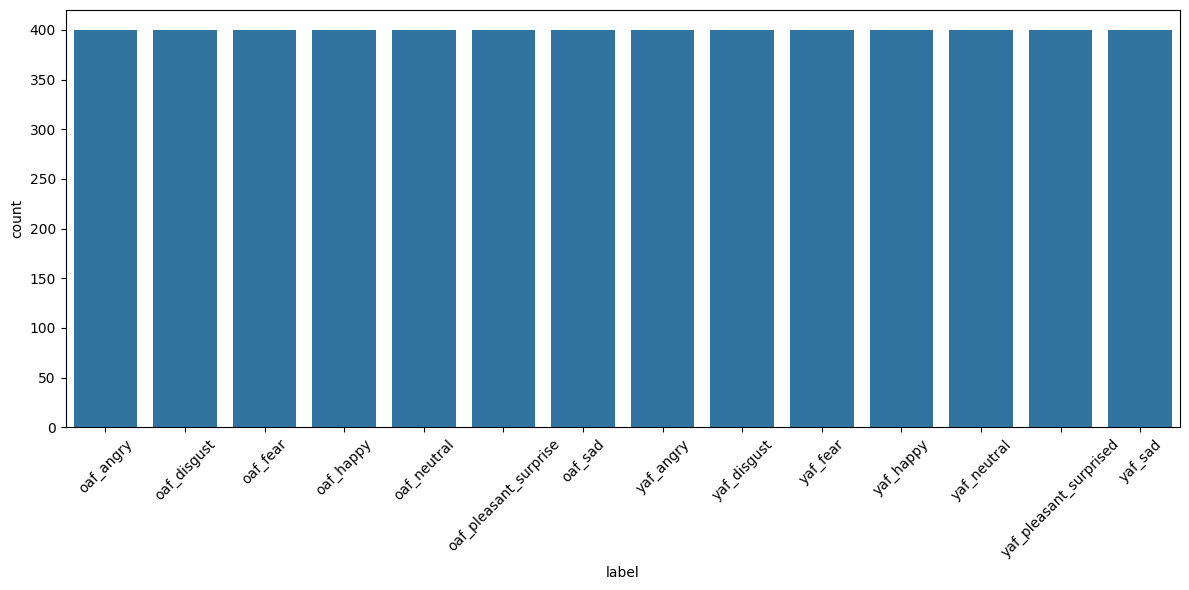

In [3]:
# Plot label distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [4]:
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

X_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))
X = np.array(X_mfcc.tolist())


In [5]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder()
y = enc.fit_transform(df[['label']]).toarray()


In [6]:
# ===================== 3. Split Data =====================
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint

def create_model(input_shape, output_classes):
    model = Sequential([
        Dense(256, input_shape=(input_shape,), activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(output_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('emotion_detection.h5', monitor='val_loss', save_best_only=True)



In [8]:
model = create_model(input_shape=X.shape[1], output_classes=y.shape[1])
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/100
 95/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0720 - loss: 23.8819   

140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0740 - loss: 19.3951 - val_accuracy: 0.0714 - val_loss: 2.6393
Epoch 2/100
122/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0698 - loss: 2.8921

140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0697 - loss: 2.8844 - val_accuracy: 0.0714 - val_loss: 2.6393
Epoch 3/100
114/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0708 - loss: 2.7224

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0710 - loss: 2.7191 - val_accuracy: 0.0714 - val_loss: 2.6393
Epoch 4/100
111/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0666 - loss: 2.6833

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0671 - loss: 2.6823 - val_accuracy: 0.0714 - val_loss: 2.6392
Epoch 5/100
131/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0720 - loss: 2.6694

...

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9787 - loss: 0.0750 - val_accuracy: 0.9973 - val_loss: 0.0058
Epoch 38/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9768 - loss: 0.0857 - val_accuracy: 0.9964 - val_loss: 0.0095
Epoch 39/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9803 - loss: 0.0746 - val_accuracy: 0.9884 - val_loss: 0.0341
Epoch 40/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9840 - loss: 0.0589 - val_accuracy: 0.9982 - val_loss: 0.0062
Epoch 41/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9878 - loss: 0.0415 - val_accuracy: 0.9973 - val_loss: 0.0067
Epoch 42/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9785 - loss: 0.0872 - val_accuracy: 0.9982 - val_loss: 0.0076
Epoch 43/100
121/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9824 - loss: 0.0685

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9823 - loss: 0.0676 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 44/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9903 - loss: 0.0410 - val_accuracy: 0.9964 - val_loss: 0.0103
Epoch 45/100
109/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9864 - loss: 0.0387

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9854 - loss: 0.0432 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 46/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9859 - loss: 0.0532 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 47/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9947 - loss: 0.0230 - val_accuracy: 0.9991 - val_loss: 0.0023
Epoch 48/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9852 - loss: 0.0429 - val_accuracy: 0.9982 - val_loss: 0.0035
Epoch 49/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9845 - loss: 0.0544 - val_accuracy: 0.9964 - val_loss: 0.0088
Epoch 50/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9900 - loss: 0.0402 - val_accuracy: 0.9955 - val_loss: 0.0197
Epoch 51/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9804 - loss: 0.0579 - val_accuracy: 0.9991 - val_loss: 0.0029
Epoch 52/100
119/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9880 - loss: 0.0394

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9878 - loss: 0.0398 - val_accuracy: 1.0000 - val_loss: 9.3865e-04
Epoch 53/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9863 - loss: 0.0399 - val_accuracy: 0.9973 - val_loss: 0.0079
Epoch 54/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9852 - loss: 0.0615 - val_accuracy: 0.9991 - val_loss: 0.0032
Epoch 55/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9830 - loss: 0.0627 - val_accuracy: 0.9991 - val_loss: 0.0042
Epoch 56/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9888 - loss: 0.0479 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 57/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9896 - loss: 0.0407 - val_accuracy: 0.9991 - val_loss: 0.0015
Epoch 58/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9869 - loss: 0.0469 - val_accuracy: 0.9982 - val_loss: 0.0029
Epoch 59/100
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9923 - loss: 0.0306

140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9923 - loss: 0.0306 - val_accuracy: 1.0000 - val_loss: 9.3718e-04
Epoch 60/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9948 - loss: 0.0352 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 61/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9935 - loss: 0.0298 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 62/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9902 - loss: 0.0364 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 63/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9901 - loss: 0.0399 - val_accuracy: 0.9982 - val_loss: 0.0046
Epoch 64/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9866 - loss: 0.0558 - val_accuracy: 0.9991 - val_loss: 0.0040
Epoch 65/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9908 - loss: 0.0288 - val_accuracy: 0.9991 - val_loss: 0.0013
Epoch 66/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9936 - loss: 0.0316 - val_accur

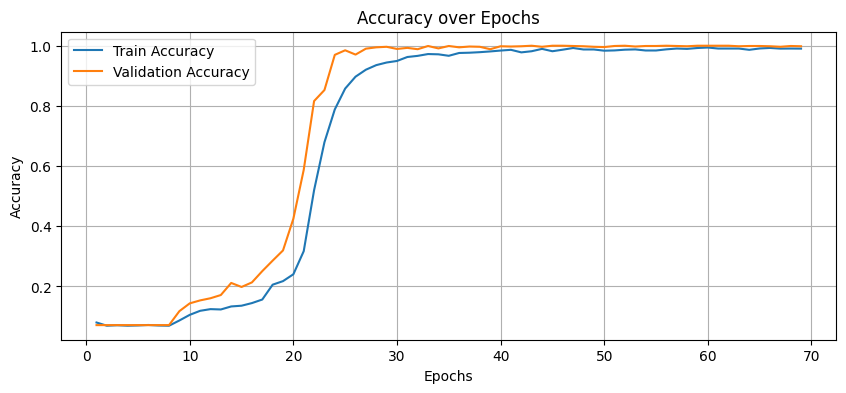

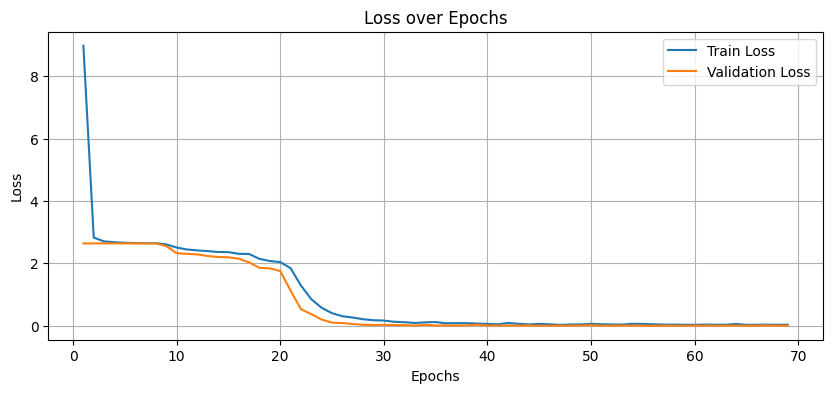

In [9]:
# ===================== 6. Plot Training History =====================
def plot_history(history):
    epochs = range(1, len(history.history['accuracy']) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history.history['loss'], label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)



In [10]:
# ===================== 7. Evaluate on Test Set =====================
from keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

# Load best model
best_model = load_model('emotion_detection.h5')

# Evaluate
loss, accuracy = best_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0010      
Test Loss: 0.0009
Test Accuracy: 1.0000


In [11]:

# Predict
y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step


In [12]:

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=enc.categories_[0]))


Classification Report:

                        precision    recall  f1-score   support

             oaf_angry       1.00      1.00      1.00        80
           oaf_disgust       1.00      1.00      1.00        80
              oaf_fear       1.00      1.00      1.00        80
             oaf_happy       1.00      1.00      1.00        80
           oaf_neutral       1.00      1.00      1.00        80
 oaf_pleasant_surprise       1.00      1.00      1.00        80
               oaf_sad       1.00      1.00      1.00        80
             yaf_angry       1.00      1.00      1.00        80
           yaf_disgust       1.00      1.00      1.00        80
              yaf_fear       1.00      1.00      1.00        80
             yaf_happy       1.00      1.00      1.00        80
           yaf_neutral       1.00      1.00      1.00        80
yaf_pleasant_surprised       1.00      1.00      1.00        80
               yaf_sad       1.00      1.00      1.00        80

             

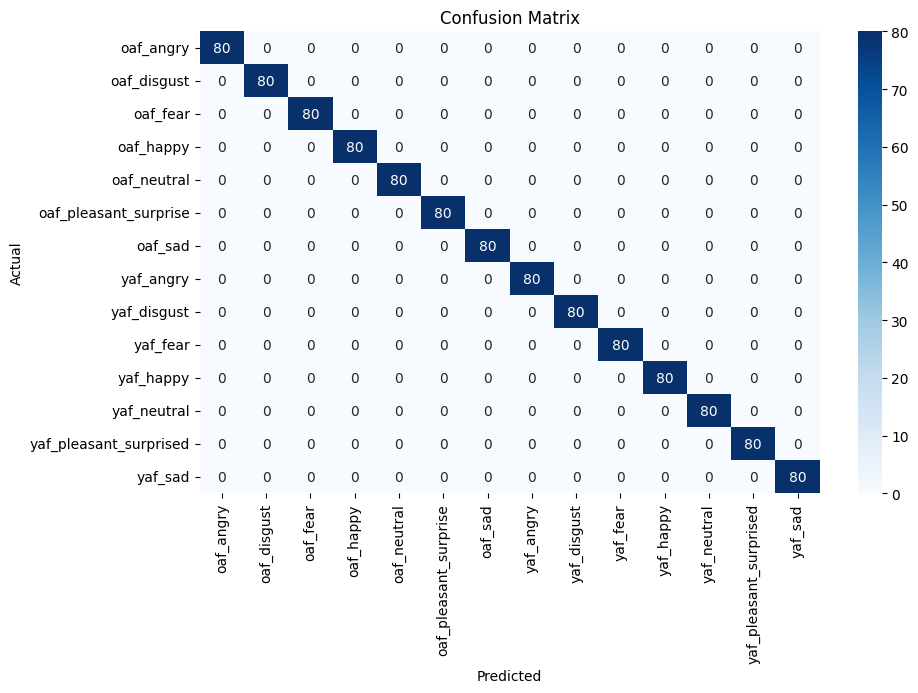

In [13]:

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=enc.categories_[0], yticklabels=enc.categories_[0], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [16]:
from keras.models import load_model
import librosa
import numpy as np

# Function to extract MFCC features (same as used for training)
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

# Load the saved model
model = load_model('emotion_detection.h5')

# Function to make predictions
def predict_emotion(file_path):
    # Extract MFCC features
    mfcc_features = extract_mfcc(file_path)
    
    # Reshape the features to match the model input shape (batch_size, features)
    mfcc_features = np.expand_dims(mfcc_features, axis=0)  # Adding the batch dimension
    
    # Predict the emotion (output will be a probability distribution)
    prediction = model.predict(mfcc_features)
    
    # Decode the prediction (get the class with the highest probability)
    predicted_class = np.argmax(prediction, axis=1)
    
    # Convert predicted class to the corresponding label (can use the label encoding from training)
    label_mapping = {0: 'oaf_angry', 1: 'oaf_disgust', 2: 'oaf_fear', 3: 'oaf_happy', 
                     4: 'oaf_neutral', 5: 'oaf_pleasant_surprise', 6: 'oaf_sad', 
                     7: 'yaf_angry', 8: 'yaf_disgust', 9: 'yaf_fear', 10: 'yaf_happy', 
                     11: 'yaf_neutral', 12: 'yaf_pleasant_surprised', 13: 'yaf_sad'}
    
    # Get the emotion label
    predicted_emotion = label_mapping[predicted_class[0]]
    
    return predicted_emotion

# Test the model with a custom .wav file
file_path = r'C:\AGE AND EMOTION DETECTOR\Toronto\OAF_Fear\OAF_bean_fear.wav'  # Replace with your file path
predicted_emotion = predict_emotion(file_path)

print(f"The predicted emotion is: {predicted_emotion}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
The predicted emotion is: oaf_fear


In [23]:
import numpy as np
import librosa
import sounddevice as sd

def extract_mfcc_from_audio(audio_data, sr=22050, n_mfcc=40):
    # Normalize the audio to float32
    audio_data = audio_data.astype(np.float32) / np.max(np.abs(audio_data))  # Normalize to [-1, 1]

    # Extract MFCC features from the recorded audio
    mfcc = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=n_mfcc)

    # Check the shape of the MFCC and adjust it to get a 1D array of size (40,)
    if mfcc.shape[1] > 1:
        # Average MFCC coefficients over time frames to get one feature per coefficient
        mfcc_mean = np.mean(mfcc, axis=1)  # Shape becomes (40,)
    else:
        # If only one time frame is present, use the MFCC directly
        mfcc_mean = mfcc.flatten()  # Shape becomes (40,)
    
    return mfcc_mean

def record_and_predict():
    # Recording parameters
    fs = 22050  # Sampling rate
    duration = 3  # seconds
    print("Recording...")
    
    # Record audio for the specified duration
    audio_data = sd.rec(int(duration * fs), samplerate=fs, channels=1, dtype='int16')
    sd.wait()  # Wait for the recording to finish
    print("Recording complete.")
    
    # Extract MFCC features from the audio
    mfcc_features = extract_mfcc_from_audio(audio_data, sr=fs)
    
    # Reshape to match the input shape of the model (1 sample, 40 features)
    mfcc_features = np.expand_dims(mfcc_features, axis=0)  # Shape becomes (1, 40)

    # Predict emotion and age using the loaded model
    predicted_emotion = model.predict(mfcc_features)  # Model expects input of shape (1, 40)
   # Assuming you have a separate model for age prediction

    return predicted_emotion, predicted_age

if __name__ == "__main__":
    while True:
        # Record and predict on audio
        predicted_emotion, predicted_age = record_and_predict()

        # Display the prediction
        print(f"Predicted Emotion: {predicted_emotion}")
        print(f"Predicted Age: {predicted_age}")


Recording...
Recording complete.


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 40, but received input with shape (1, 66150)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 66150, 1), dtype=float32)
  • training=False
  • mask=None